In [349]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [350]:
odr = pd.read_csv("data/age-dependency-ratio-old.csv")
schooling = pd.read_csv("data/average-years-of-schooling-among-adults.csv")
rd = pd.read_csv("data/research-spending-gdp.csv")
internet = pd.read_csv("data/share-of-individuals-using-the-internet.csv")
gdp_pc_long = pd.read_csv("data/gdp-per-capita-worldbank.csv")

In [351]:
odr = odr.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Age dependency ratio, old (% of working-age population)": "odr"
})

schooling = schooling.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Both genders": "schooling"
})

rd = rd.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Research and development expenditure (% of GDP)": "rd"
})

internet = internet.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Share of the population using the Internet": "internet_use"
})

gdp_pc_long = gdp_pc_long.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "GDP per capita": "gdppc",
})

print("ODR columns:", odr.columns.tolist())
print("Schooling columns:", schooling.columns.tolist())
print("R&D columns:", rd.columns.tolist())
print("Internet columns:", internet.columns.tolist())
print("GDP pc columns:", gdp_pc_long.columns.tolist())

ODR columns: ['country', 'code', 'year', 'odr']
Schooling columns: ['country', 'code', 'year', 'schooling']
R&D columns: ['country', 'code', 'year', 'rd']
Internet columns: ['country', 'code', 'year', 'internet_use']
GDP pc columns: ['country', 'code', 'year', 'gdppc', 'World region according to OWID']


Merge datasættene sammen

In [352]:
start = 2001
end = 2020

for df in [odr, schooling, rd, internet]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

odr = odr[(odr["year"] >= start) & (odr["year"] <= end)]
schooling = schooling[(schooling["year"] >= start) & (schooling["year"] <= end)]
rd = rd[(rd["year"] >= start) & (rd["year"] <= end)]
internet = internet[(internet["year"] >= start) & (internet["year"] <= end)]
gdp_pc_long = gdp_pc_long[(gdp_pc_long["year"] >= start) & (gdp_pc_long["year"] <= end)]

In [353]:
panel2 = internet[["country", "code", "year", "internet_use"]].merge(
    odr[["code", "year", "odr"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    rd[["code", "year", "rd"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    schooling[["code", "year", "schooling"]],
    on=["code", "year"],
    how="inner"
)

panel2 = panel2.merge(
    gdp_pc_long[["code", "year", "gdppc"]],
    on=["code", "year"],
    how="inner"
)



In [354]:
panel2["log_gdp_pc"] = np.log(panel2["gdppc"])
panel2["log_internet_use"] = np.log(panel2["internet_use"])

print(panel2.head())
print(panel2.shape)
print(panel2["code"].nunique())

   country code  year  internet_use        odr       rd  schooling      gdppc  \
0  Albania  ALB  2007     15.036100  14.793774  0.08757   9.214286  10262.967   
1  Albania  ALB  2008     23.860000  15.311145  0.15412   9.280000  11056.352   
2  Algeria  DZA  2001      0.646114   7.093249  0.21219   5.683261  11742.595   
3  Algeria  DZA  2002      1.591640   7.109899  0.33807   5.757431  12213.126   
4  Algeria  DZA  2003      2.195360   7.130257  0.18122   5.831600  12835.182   

   log_gdp_pc  log_internet_use  
0    9.236297          2.710454  
1    9.310760          3.172203  
2    9.370978         -0.436779  
3    9.410267          0.464765  
4    9.459945          0.786346  
(1751, 10)
140


In [355]:
years_per_country = panel2.groupby("code")["year"].nunique().reset_index()
years_per_country = years_per_country.rename(columns={"year": "n_years"})

print(years_per_country.sort_values("n_years"))

    code  n_years
0    AGO        1
85   MRT        1
101  PNG        1
23   CIV        1
26   CPV        1
..   ...      ...
50   HUN       20
49   HRV       20
9    BEL       20
102  POL       20
38   FIN       20

[140 rows x 2 columns]


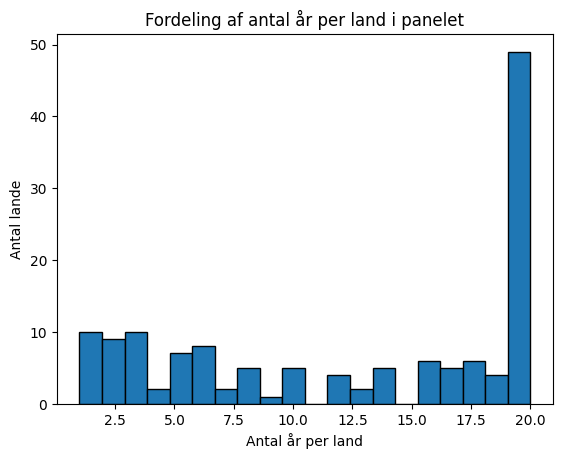

In [356]:
import matplotlib.pyplot as plt

plt.hist(years_per_country["n_years"], bins=20, edgecolor="black")
plt.xlabel("Antal år per land")
plt.ylabel("Antal lande")
plt.title("Fordeling af antal år per land i panelet")
plt.show()

Det er et balanceret panel.

### korrelationer

    year  n_countries
0   2001           77
1   2002           87
2   2003           80
3   2004           82
4   2005           85
5   2006           80
6   2007           92
7   2008           93
8   2009           91
9   2010           89
10  2011           89
11  2012           83
12  2013           90
13  2014           88
14  2015           99
15  2016           90
16  2017           94
17  2018           89
18  2019           90
19  2020           83


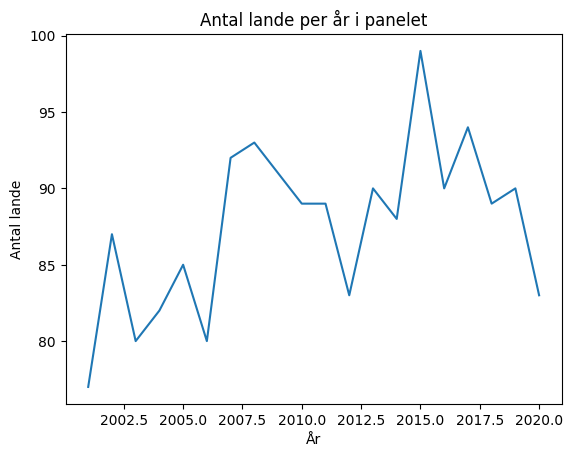

In [357]:
years_coverage = panel2.groupby("year")["code"].nunique().reset_index()
years_coverage = years_coverage.rename(columns={"code": "n_countries"})

print(years_coverage)

import matplotlib.pyplot as plt

plt.plot(years_coverage["year"], years_coverage["n_countries"])
plt.xlabel("År")
plt.ylabel("Antal lande")
plt.title("Antal lande per år i panelet")
plt.show()

### Visuelt korrelationer

In [358]:
panel2 = panel2[(panel2["year"] >= 2002) & (panel2["year"] <= 2020)].copy()

In [359]:
years_per_country = panel2.groupby(["country", "code"])["year"].nunique().reset_index()
years_per_country = years_per_country.rename(columns={"year": "n_years"})

eligible_codes = years_per_country[years_per_country["n_years"] == 19]["code"]

panel2_balanced = panel2[panel2["code"].isin(eligible_codes)].copy()

In [360]:
print("Antal lande:", panel2_balanced["code"].nunique())
print("Antal observationer:", len(panel2_balanced))
print(panel2_balanced.groupby("code")["year"].nunique().value_counts())

Antal lande: 50
Antal observationer: 950
year
19    50
Name: count, dtype: int64


In [361]:
country_list = (
    panel2_balanced[["country", "code"]]
    .drop_duplicates()
    .sort_values("country")
    .reset_index(drop=True)
)

#make a copy of the dataframe
df_mean = panel2_balanced.copy()

# remove the year 2002 for each country
df_mean = df_mean[df_mean["year"] != 2001]

# Lav 2-års blokke med start i 2002
df_mean["period_2yr"] = ((df_mean["year"] - 2002) // 2)

# Beregn gennemsnit af odr inden for hvert land og hver 2-års blok
df_mean["odr_2year_mean"] = (
    df_mean
    .groupby(["code", "period_2yr"])["odr"]
    .transform("mean")
)
# Lav 3-års blokke med start i 2002
df_mean["period_3yr"] = ((df_mean["year"] - 2002) // 3)

# Beregn gennemsnit af odr inden for hvert land og hver 3-års blok
df_mean["odr_3year_mean"] = (
    df_mean
    .groupby(["code", "period_3yr"])["odr"]
    .transform("mean")
)

# Hvis du ikke vil beholde hjælpekolonnen
df_mean = df_mean.drop(columns="period_3yr")

# Lav 6-års blokke med start i 2002
df_mean["period_6yr"] = ((df_mean["year"] - 2002) // 6)

# Beregn gennemsnit af odr inden for hvert land og hver 6-års blok
df_mean["odr_6year_mean"] = (
    df_mean
    .groupby(["code", "period_6yr"])["odr"]
    .transform("mean")
)

# Hvis du ikke vil beholde hjælpekolonnen
df_mean = df_mean.drop(columns="period_6yr")

df_mean.loc[
    df_mean["code"] == "DNK",
    ["code", "year", "odr","odr_2year_mean", "odr_3year_mean", "odr_6year_mean"]
].head(10)

panel2_balanced = df_mean.copy()
#with open("country_list.txt", "w", encoding="utf-8") as f:
#    for _, row in country_list.iterrows():
#        f.write(f'{row["country"]} ({row["code"]})\n')

# lav log af BNP pr. capita
panel2_balanced["log_gdppc"] = np.log(panel2_balanced["gdppc"])

In [362]:
print(panel2_balanced[["internet_use", "odr", "rd", "schooling", "gdppc"]].isna().sum())

internet_use    0
odr             0
rd              0
schooling       0
gdppc           0
dtype: int64


In [363]:
# kopi af det færdige balanced panel
df_est = panel2_balanced.copy()

# estimation
model3 = smf.ols(
    "log_internet_use ~ odr + rd + log_gdppc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "rd", "log_gdppc"]],
    "std_err": results3.bse[["odr", "rd", "log_gdppc"]],
    "p_value": results3.pvalues[["odr", "rd", "log_gdppc"]],
})

print(main_results3.round(4))

             coef  std_err  p_value
odr       -0.1241   0.0310   0.0001
rd        -0.3979   0.1116   0.0004
log_gdppc  1.1341   0.2405   0.0000


In [364]:
# kopi af det færdige balanced panel
df_est = panel2_balanced.copy()

# estimation
model3 = smf.ols(
    "log_internet_use ~ odr_6year_mean + rd + log_gdppc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr_6year_mean", "rd", "log_gdppc"]],
    "std_err": results3.bse[["odr_6year_mean", "rd", "log_gdppc"]],
    "p_value": results3.pvalues[["odr_6year_mean", "rd", "log_gdppc"]],
})

print(main_results3.round(4))

                  coef  std_err  p_value
odr_6year_mean -0.1298   0.0335   0.0001
rd             -0.4051   0.1133   0.0003
log_gdppc       1.1335   0.2427   0.0000


## Alternative modeller

In [365]:
# kopi af det færdige balanced panel
df_est = panel2_balanced.copy()

# estimation
model3 = smf.ols(
    "internet_use ~ odr + schooling + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "schooling"]],
    "std_err": results3.bse[["odr", "schooling"]],
    "p_value": results3.pvalues[["odr", "schooling"]],
})

print(main_results3.round(4))

             coef  std_err  p_value
odr       -1.9672   0.6700   0.0033
schooling  3.3336   2.3089   0.1488


In [366]:
# kopi af det færdige balanced panel
df_est = panel2_balanced.copy()

# estimation
model3 = smf.ols(
    "internet_use ~ odr + rd + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "rd"]],
    "std_err": results3.bse[["odr", "rd"]],
    "p_value": results3.pvalues[["odr", "rd"]],
})

print(main_results3.round(4))

       coef  std_err  p_value
odr -1.9489   0.6193   0.0016
rd  -4.6196   2.7934   0.0982


In [367]:
# kopi af det færdige balanced panel
df_est = panel2_balanced.copy()

# estimation
model3 = smf.ols(
    "internet_use ~ odr + log_gdppc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_gdppc"]],
    "std_err": results3.bse[["odr", "log_gdppc"]],
    "p_value": results3.pvalues[["odr", "log_gdppc"]],
})

print(main_results3.round(4))

             coef  std_err  p_value
odr       -2.0059   0.6458   0.0019
log_gdppc  4.5152   7.5040   0.5474


In [368]:

# kopi af det færdige balanced panel
df_est = panel2_balanced.copy()
# estimation
model3 = smf.ols(
    "internet_use ~ odr + rd + schooling + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "rd", "schooling"]],
    "std_err": results3.bse[["odr", "rd", "schooling"]],
    "p_value": results3.pvalues[["odr", "rd", "schooling"]],
})

print(main_results3.round(4))

             coef  std_err  p_value
odr       -1.8247   0.6453   0.0047
rd        -5.1940   2.7468   0.0586
schooling  3.7810   2.1064   0.0726


## Verificering

In [369]:
# kopi af det færdige balanced panel
df_est = panel2_balanced.copy()

# estimation
model3 = smf.ols(
    "log_internet_use ~ odr + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr"]],
    "std_err": results3.bse[["odr"]],
    "p_value": results3.pvalues[["odr"]],
})

print(main_results3.round(4))

       coef  std_err  p_value
odr -0.1486   0.0378   0.0001


In [370]:
# kopi af det færdige balanced panel
df_est = panel2_balanced.copy()

# estimation
model3 = smf.ols(
    "log_internet_use ~ odr + rd  + log_gdppc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "rd", "log_gdppc"  ]],
    "std_err": results3.bse[["odr", "rd", "log_gdppc"]],
    "p_value": results3.pvalues[["odr", "rd", "log_gdppc"]],
})

print(main_results3.round(4))

             coef  std_err  p_value
odr       -0.1241   0.0310   0.0001
rd        -0.3979   0.1116   0.0004
log_gdppc  1.1341   0.2405   0.0000


In [371]:
# kopi af det færdige balanced panel
df_est = panel2_balanced.copy()

# estimation
model3 = smf.ols(
    "log_internet_use ~ odr_2year_mean + rd + log_gdppc  + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr_2year_mean", "rd", "log_gdppc"]],
    "std_err": results3.bse[["odr_2year_mean", "rd", "log_gdppc"]],
    "p_value": results3.pvalues[["odr_2year_mean", "rd", "log_gdppc"]],
})

print(main_results3.round(4))

                  coef  std_err  p_value
odr_2year_mean -0.1245   0.0312   0.0001
rd             -0.3984   0.1119   0.0004
log_gdppc       1.1340   0.2407   0.0000


## Lagged ORD

In [372]:
df_lag = panel2_balanced.copy()
df_lag = df_lag.sort_values(["code", "year"])

# Lav lagget ODR inden for hvert land
df_lag["odr_l1"] = df_lag.groupby("code")["odr"].shift(1)

# Log af internet use og GDP per capita
df_lag["log_internet_use"] = np.log(df_lag["internet_use"])
df_lag["log_gdppc"] = np.log(df_lag["gdppc"])

# Fjern første år per land og evt. andre manglende værdier
df_lag = df_lag.dropna(subset=["log_internet_use", "odr_l1", "rd", "log_gdppc"]).copy()

# Estimér lagged model
model_lag = smf.ols(
    "log_internet_use ~ odr_l1 + rd + log_gdppc + C(code) + C(year)",
    data=df_lag
)

results_lag = model_lag.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_lag["code"]}
)

main_results_lag = pd.DataFrame({
    "coef": results_lag.params[["odr_l1", "rd", "log_gdppc"]],
    "std_err": results_lag.bse[["odr_l1", "rd", "log_gdppc"]],
    "p_value": results_lag.pvalues[["odr_l1", "rd", "log_gdppc"]],
})

print(main_results_lag.round(4))

             coef  std_err  p_value
odr_l1    -0.1244   0.0318   0.0001
rd        -0.3814   0.1089   0.0005
log_gdppc  1.0476   0.2376   0.0000


In [373]:
#panel2_balanced.to_csv("panel2_balanced.csv", index=False)
print(panel2_balanced["code"].nunique())

50


## Deskriptiv

In [374]:
df_desc = panel2_balanced.copy()
df_desc["log_internet_use"] = np.log(df_desc["internet_use"])
df_desc["log_gdppc"] = np.log(df_desc["gdppc"])

desc_table = df_desc[["internet_use", "log_internet_use", "odr", "rd", "gdppc", "log_gdppc"]].describe().T
print(desc_table.round(3))

                  count       mean        std       min        25%        50%  \
internet_use      950.0     58.453     26.044     1.082     39.930     64.752   
log_internet_use  950.0      3.874      0.782     0.079      3.687      4.171   
odr               950.0     20.160      8.258     2.299     13.171     20.961   
rd                950.0      1.315      1.046     0.031      0.472      1.053   
gdppc             950.0  37910.396  20639.083  3250.696  21855.788  35814.346   
log_gdppc         950.0     10.355      0.684     8.087      9.992     10.486   

                        75%         max  
internet_use         79.440      99.599  
log_internet_use      4.375       4.601  
odr                  26.195      48.980  
rd                    1.972       5.797  
gdppc             51625.714  120114.130  
log_gdppc            10.852      11.696  


In [375]:
desc_table = df_desc[["internet_use", "log_internet_use", "odr", "rd", "gdppc", "log_gdppc"]].agg(
    ["count", "mean", "std", "min", "median", "max"]
).T

print(desc_table.round(3))

                  count       mean        std       min     median         max
internet_use      950.0     58.453     26.044     1.082     64.752      99.599
log_internet_use  950.0      3.874      0.782     0.079      4.171       4.601
odr               950.0     20.160      8.258     2.299     20.961      48.980
rd                950.0      1.315      1.046     0.031      1.053       5.797
gdppc             950.0  37910.396  20639.083  3250.696  35814.346  120114.130
log_gdppc         950.0     10.355      0.684     8.087     10.486      11.696


In [376]:
print("Antal lande:", df_desc["code"].nunique())
print("Antal observationer:", len(df_desc))
print("Periode:", df_desc["year"].min(), "-", df_desc["year"].max())

Antal lande: 50
Antal observationer: 950
Periode: 2002 - 2020


In [377]:
year_means = df_desc.groupby("year")[["internet_use", "odr", "rd", "gdppc"]].mean()
print(year_means.round(3))

      internet_use     odr     rd      gdppc
year                                        
2002        26.689  17.406  1.128  31153.075
2003        31.243  17.618  1.133  32089.329
2004        35.489  17.846  1.139  33467.106
2005        38.657  18.080  1.159  34737.569
2006        42.201  18.296  1.182  36213.562
2007        46.989  18.475  1.206  37669.098
2008        50.852  18.633  1.255  37885.104
2009        54.792  18.832  1.301  35969.589
2010        58.537  19.065  1.298  36887.917
2011        61.234  19.408  1.343  37777.544
2012        64.033  19.895  1.367  38041.392
2013        66.533  20.434  1.381  38434.412
2014        69.068  21.003  1.412  39110.727
2015        71.182  21.579  1.413  40049.183
2016        73.869  22.147  1.378  40648.531
2017        75.991  22.725  1.393  41876.241
2018        78.563  23.291  1.435  42899.413
2019        80.981  23.866  1.484  43638.529
2020        83.700  24.447  1.573  41749.205


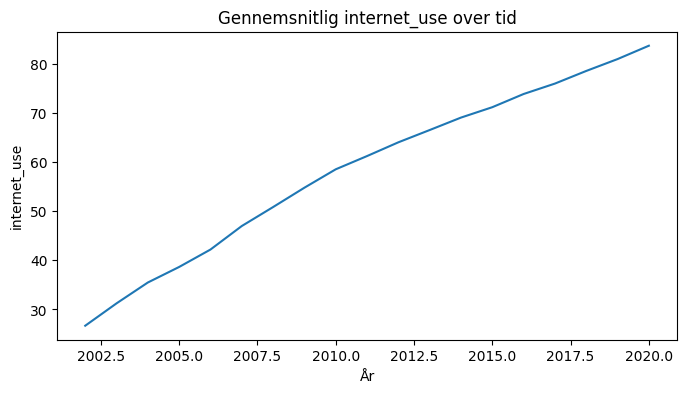

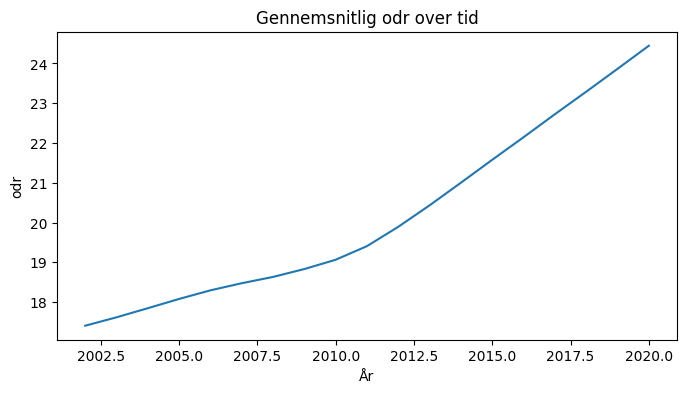

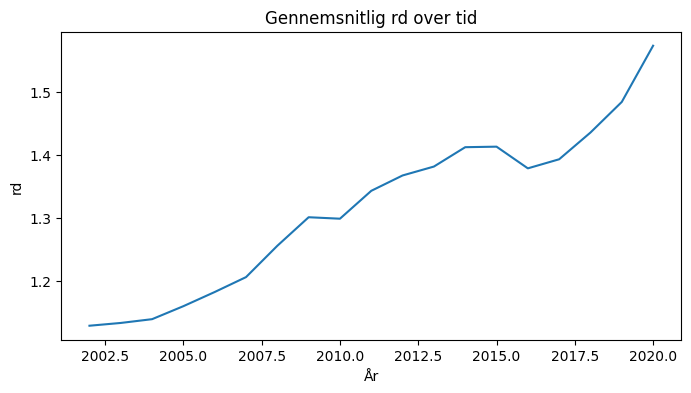

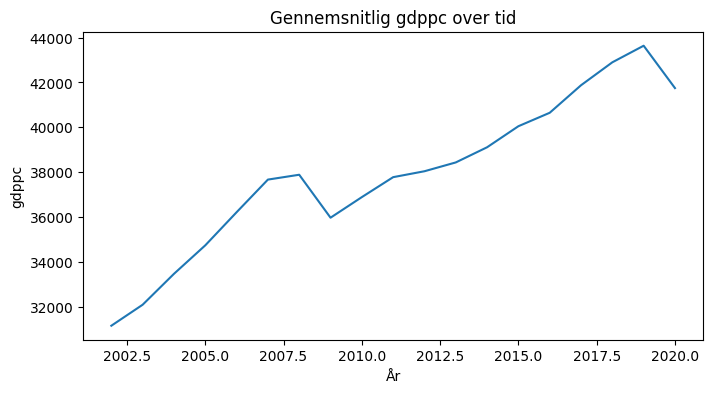

In [378]:
import matplotlib.pyplot as plt

for var in ["internet_use", "odr", "rd", "gdppc"]:
    plt.figure(figsize=(8,4))
    plt.plot(year_means.index, year_means[var])
    plt.xlabel("År")
    plt.ylabel(var)
    plt.title(f"Gennemsnitlig {var} over tid")
    plt.show()

In [379]:
df = panel2_balanced.copy()
df = df.sort_values(["code", "year"])

# Hældning over tid for hvert land
slopes = df.groupby(["country", "code"]).apply(
    lambda g: pd.Series({
        "internet_slope": np.polyfit(g["year"], g["internet_use"], 1)[0],
        "odr_slope": np.polyfit(g["year"], g["odr"], 1)[0]
    })
).reset_index()

# År-til-år ændringer i internet_use
df["internet_diff"] = df.groupby("code")["internet_use"].diff()

neg_counts = df.groupby(["country", "code"])["internet_diff"].apply(
    lambda s: (s < 0).sum()
).reset_index(name="n_negative_years")

# Saml oversigt
country_overview = slopes.merge(neg_counts, on=["country", "code"], how="left")

print("Lande med negativ samlet internettrend:")
print(country_overview[country_overview["internet_slope"] < 0])

print("\nLande med flest negative enkeltår:")
print(country_overview.sort_values("n_negative_years", ascending=False).head(15))

Lande med negativ samlet internettrend:
Empty DataFrame
Columns: [country, code, internet_slope, odr_slope, n_negative_years]
Index: []

Lande med flest negative enkeltår:
          country code  internet_slope  odr_slope  n_negative_years
39      Singapore  SGP        2.155102   0.326777                 5
31    Netherlands  NLD        1.437526   0.595892                 4
48  United States  USA        1.526346   0.375673                 4
14        Finland  FIN        1.257196   0.800658                 4
18        Hungary  HUN        3.434792   0.471723                 3
33         Norway  NOR        1.246222   0.268314                 3
40       Slovakia  SVK        2.389387   0.463565                 3
23          Japan  JPN        2.337988   1.284126                 3
12        Denmark  DNK        1.429289   0.566736                 3
13        Estonia  EST        2.575338   0.471849                 2
41       Slovenia  SVN        2.865369   0.576837                 2
22          

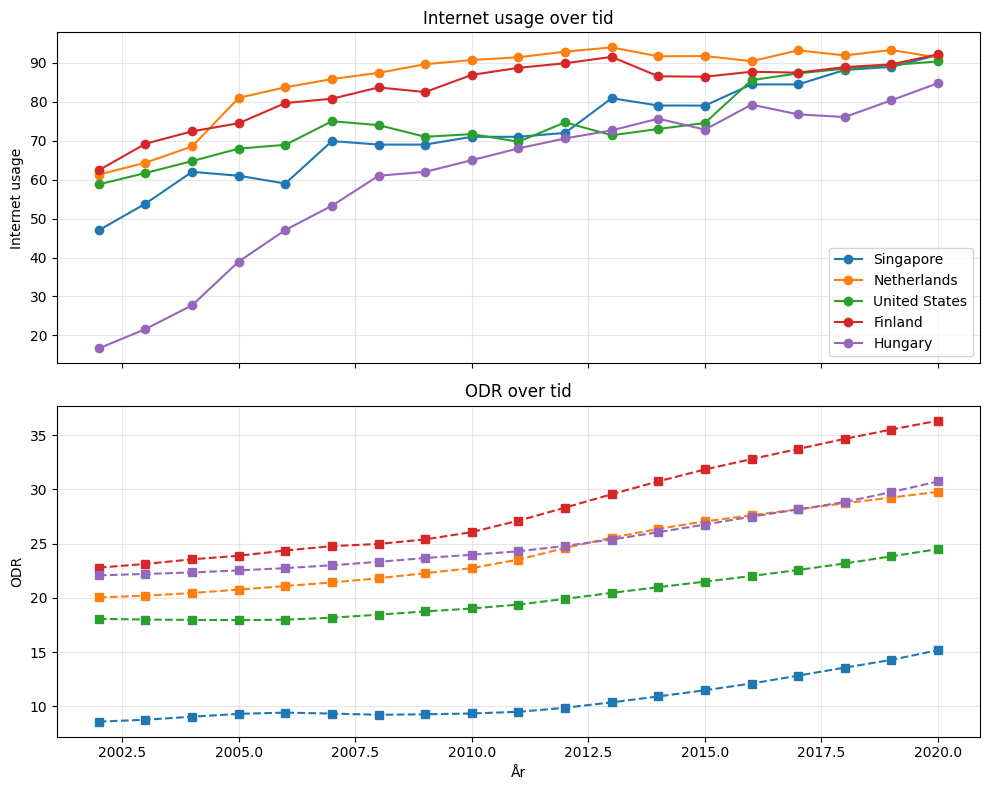

In [380]:
import matplotlib.pyplot as plt

selected_countries = ["Singapore", "Netherlands", "United States", "Finland", "Hungary"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for country in selected_countries:
    temp = panel2_balanced[panel2_balanced["country"] == country].sort_values("year")
    
    ax1.plot(temp["year"], temp["internet_use"], marker="o", label=country)
    ax2.plot(temp["year"], temp["odr"], marker="s", linestyle="--", label=country)

ax1.set_title("Internet usage over tid")
ax1.set_ylabel("Internet usage")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.set_title("ODR over tid")
ax2.set_xlabel("År")
ax2.set_ylabel("ODR")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()